# Вопрос 03. Байесовский и минимаксный подходы — численные примеры

Файл ведётся в формате jupytext (percent). Парный `.ipynb` получается
командой `make questions/03-decision-bayes-minimax/examples.ipynb`.

Правила: каждый пример отвечает на вопрос из `theory.md`; seed задан явно;
число, попавшее в `theory.md` или `slides.md`, печатается здесь.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, optimize, stats

SEED = 20261003
rng = np.random.default_rng(SEED)

FIGDIR = "figures"

# PDF metadata carries a creation timestamp, so an unchanged figure gets new
# bytes on every rebuild and `git diff` stops telling content from clock.
SAVE_KW = {"metadata": {"CreationDate": None}}

# Golden pins: the seed and the expected outputs are fixed constants. Without
# them "reproducibility" is checked by consistency of a run with itself, which
# means nothing. A mismatch fails the notebook build, so it works as a gate.
GOLDEN = {
    "r0_true": 2.1,
    "r0_bayes": 2.0951475,
    "r0_mle": 2.0948246,
    "mse_bayes": 0.00020438547,
    "mse_mle": 0.00021045612,
    "mse_bayes_far": 0.0060064401,
    "mse_mle_far": 0.0060290294,
    "risk_xbar": 0.04,
    "risk_shrunk_0": 0.036982248,
    "bayes_risk_shrunk_tau1": 0.038461539,
    "bayes_risk_shrunk_tau10": 0.039840637,
    "minimax_value": 0.35,
    "pfa_star": 0.35,
    "det_best": 0.5,
}
TOL = 1e-3


def check_golden(name, value, tol=TOL):
    want = GOLDEN[name]
    rel = abs(value - want) / abs(want)
    print(f"  пин {name}: получено {value:.12g}, ожидалось {want:.12g}")
    assert rel <= tol, f"golden-пин {name} не сошёлся: {value} vs {want}"

## Пример 1. SIR-модель: байесовская оценка $R_0$ против максимального правдоподобия

**Вопрос (theory.md, раздел «Байесовский подход»):** сквозной пример — по
дневной заболеваемости оценить $\beta$, $\gamma$ и $R_0 = \beta/\gamma$.
Априорные по Л1: $\beta \sim \mathrm{Exp}$ («положительно и не огромно»),
$\gamma$ — узкое распределение около $1/7$; правдоподобие Пуассона.

**Предсказание (до прогона).** Истина $\beta = 0{,}3$, $\gamma = 1/7$
($R_0 = 2{,}1$) лежит внутри априорной массы. Байесовская оценка (апостериорное
среднее $R_0$) должна оказаться ближе к истине, чем оценка максимального
правдоподобия, а по ансамблю из шумных данных её MSE должен быть меньше;
разница должна заметно уменьшиться, если истину сместить далеко от априорного
центра (проверка второго утверждения — той же функцией, с другой истиной).

In [2]:
# SIR in absolute numbers; daily new cases are exactly S(t-1) - S(t).
N_POP = 100_000
I0 = 10.0
T_DAYS = 80
TRUE_BETA, TRUE_GAMMA = 0.3, 1.0 / 7.0


def sir_daily_infect(beta, gamma, n_pop=N_POP, i0=I0, days=T_DAYS):
    """Daily new cases S(t-1) - S(t) for the SIR model."""

    def rhs(t, y):
        s, i, r = y
        return [-beta * s * i / n_pop,
                beta * s * i / n_pop - gamma * i,
                gamma * i]

    sol = integrate.solve_ivp(rhs, (0.0, float(days)), [n_pop - i0, i0, 0.0],
                             t_eval=np.arange(0, days + 1),
                             rtol=1e-6, atol=1e-8)
    s = sol.y[0]
    return s[:-1] - s[1:]  # lambda_t = S(t-1) - S(t) >= 0, t = 1..days


lam_true = sir_daily_infect(TRUE_BETA, TRUE_GAMMA)
y_obs = rng.poisson(lam_true)

# Priors (Lecture L1): beta ~ Exp(rate=2) ("positive, not huge"),
# gamma ~ Gamma(k=100) concentrated near 1/7.
PRIOR_BETA_RATE = 2.0
PRIOR_GAMMA_SHAPE = 100.0
PRIOR_GAMMA_SCALE = (1.0 / 7.0) / PRIOR_GAMMA_SHAPE


def log_posterior(log_params, y, with_priors=True):
    """Log posterior in log-parameter space (keeps beta, gamma positive)."""
    beta, gamma = np.exp(log_params)
    lam = sir_daily_infect(beta, gamma)
    ll = np.sum(stats.poisson.logpmf(y, lam))
    if not with_priors:
        return ll
    lp = stats.expon.logpdf(beta, scale=1.0 / PRIOR_BETA_RATE) \
        + stats.gamma.logpdf(gamma, a=PRIOR_GAMMA_SHAPE, scale=PRIOR_GAMMA_SCALE)
    return ll + lp


def neg_log_post(log_params, y, with_priors=True):
    val = log_posterior(log_params, y, with_priors)
    return -val if np.isfinite(val) else 1e12


def grad(f, x, rel=1e-4):
    """Central finite differences of the gradient."""
    n = len(x)
    gv = np.empty(n)
    for j in range(n):
        h = rel * max(abs(x[j]), 1.0)
        step = np.zeros(n)
        step[j] = h
        gv[j] = (f(x + step) - f(x - step)) / (2 * h)
    return gv


def hessian(f, x, rel=1e-3):
    """Central finite differences of the Hessian (two applications)."""
    n = len(x)
    H = np.empty((n, n))
    for j in range(n):
        h = rel * max(abs(x[j]), 1.0)
        step = np.zeros(n)
        step[j] = h
        H[:, j] = (grad(f, x + step) - grad(f, x - step)) / (2 * h)
    return (H + H.T) / 2


def fit_map(y, with_priors=True):
    # multi-start: the Poisson likelihood over (log beta, log gamma) is not concave
    starts = [np.log([0.2, 0.12]), np.log([0.3, 0.14]),
              np.log([0.5, 0.2]), np.log([0.15, 0.1])]
    obj = lambda lp: neg_log_post(lp, y, with_priors)
    best = None
    for s0 in starts:
        res = optimize.minimize(obj, s0, method="Nelder-Mead",
                                options={"xatol": 1e-5, "fatol": 1e-8, "maxiter": 600})
        if best is None or res.fun < best.fun:
            best = res
    log_map = best.x
    hess = hessian(obj, log_map)
    # Laplace covariance in log-space; delta method to (beta, gamma)-space
    cov_log = np.linalg.inv(hess)
    jac = np.diag(np.exp(log_map))
    cov = jac @ cov_log @ jac.T
    return np.exp(log_map), cov


map_est, post_cov = fit_map(y_obs, with_priors=True)
mle_est, _ = fit_map(y_obs, with_priors=False)

# Curvature of the likelihood at the MLE: eigenvalues of the Hessian of the
# negative log-likelihood in log-parameter space (the "10^6" claim below)
mle_hess = hessian(lambda lp: neg_log_post(lp, y_obs, with_priors=False),
                   np.log(mle_est))
eigs = np.linalg.eigvalsh(mle_hess)
print(f"крутизна правдоподобия: собственные значения гессиана -log L "
      f"в лог-пространстве (ОМП) = {eigs[0]:.4g}, {eigs[1]:.4g}")

# Posterior samples for R0 under the Laplace approximation (reject nonpositive)
post_rng = np.random.default_rng([SEED, 1])
samples = post_rng.multivariate_normal(map_est, post_cov, size=40_000)
samples = samples[(samples[:, 0] > 0) & (samples[:, 1] > 0)]
r0_samples = samples[:, 0] / samples[:, 1]
r0_true = TRUE_BETA / TRUE_GAMMA
r0_bayes = r0_samples.mean()
r0_mle = mle_est[0] / mle_est[1]
r0_ci = np.quantile(r0_samples, [0.025, 0.975])

print(f"истина:      beta={TRUE_BETA:.4f}  gamma={TRUE_GAMMA:.4f}  R0={r0_true:.4f}")
print(f"MAP:         beta={map_est[0]:.6f}  gamma={map_est[1]:.6f}")
print(f"ОМП:         beta={mle_est[0]:.6f}  gamma={mle_est[1]:.6f}")
print(f"R0 байес:    {r0_bayes:.8g}  (95% интервал {r0_ci[0]:.6g}..{r0_ci[1]:.6g})")
print(f"R0 ОМП:      {r0_mle:.8g}")
print(f"отклонение байес от истины: {abs(r0_bayes - r0_true):.8g}")
print(f"отклонение ОМП от истины:   {abs(r0_mle - r0_true):.8g}")
check_golden("r0_true", r0_true)
check_golden("r0_bayes", r0_bayes)
check_golden("r0_mle", r0_mle)

крутизна правдоподобия: собственные значения гессиана -log L в лог-пространстве (ОМП) = 7822, 4.519e+06
истина:      beta=0.3000  gamma=0.1429  R0=2.1000
MAP:         beta=0.300634  gamma=0.143498
ОМП:         beta=0.300658  gamma=0.143524
R0 байес:    2.0951475  (95% интервал 2.07151..2.11974)
R0 ОМП:      2.0948246
отклонение байес от истины: 0.0048524622
отклонение ОМП от истины:   0.0051754093
  пин r0_true: получено 2.1, ожидалось 2.1
  пин r0_bayes: получено 2.09514753781, ожидалось 2.0951475
  пин r0_mle: получено 2.09482459075, ожидалось 2.0948246


**Риск по ансамблю шума:** для той же истины повторяем оценивание по
репликациям шума и меряем MSE обеих оценок. Предсказание: MSE байесовской
оценки меньше (истина внутри априорной массы). Тот же счёт со смещённой
истиной $\beta = 0{,}9$ (за пределами типичной априорной массы $\mathrm{Exp}(2)$)
проверяет вторую сторону сделки: если данные слабо информативны, сжатие к
априорному центру должно навредить; если данные сильны, правдоподобие
подавляет априорное и оценки совпадают — различие исчезает.

In [3]:
def ensemble_mse(true_beta, true_gamma, n_rep=12):
    lam = sir_daily_infect(true_beta, true_gamma)
    rep_rng = np.random.default_rng([SEED, 2])
    se_bayes, se_mle = 0.0, 0.0
    for rep in range(n_rep):
        y_rep = rep_rng.poisson(lam)
        b_map, b_cov = fit_map(y_rep, with_priors=True)
        b_mle, _ = fit_map(y_rep, with_priors=False)
        # Bayes rule under quadratic loss: posterior mean of R0 (Laplace samples)
        smp = np.random.default_rng([SEED, 2, rep]).multivariate_normal(b_map, b_cov, size=4000)
        smp = smp[(smp[:, 0] > 0) & (smp[:, 1] > 0)]
        r0_b = np.mean(smp[:, 0] / smp[:, 1])
        r0_m = b_mle[0] / b_mle[1]
        se_bayes += (r0_b - true_beta / true_gamma) ** 2
        se_mle += (r0_m - true_beta / true_gamma) ** 2
    return se_bayes / n_rep, se_mle / n_rep


mse_bayes, mse_mle = ensemble_mse(TRUE_BETA, TRUE_GAMMA)
print(f"истина внутри априорной массы (R0=2.1):")
print(f"  MSE байес: {mse_bayes:.8g}   MSE ОМП: {mse_mle:.8g}")
mse_bayes_far, mse_mle_far = ensemble_mse(0.9, TRUE_GAMMA)
print(f"истина за пределами априорной массы (beta=0.9, R0=6.3):")
print(f"  MSE байес: {mse_bayes_far:.8g}   MSE ОМП: {mse_mle_far:.8g}")
check_golden("mse_bayes", mse_bayes)
check_golden("mse_mle", mse_mle)
check_golden("mse_bayes_far", mse_bayes_far)
check_golden("mse_mle_far", mse_mle_far)

истина внутри априорной массы (R0=2.1):
  MSE байес: 0.00020438547   MSE ОМП: 0.00021045612


истина за пределами априорной массы (beta=0.9, R0=6.3):
  MSE байес: 0.0060064401   MSE ОМП: 0.0060290294
  пин mse_bayes: получено 0.000204385474454, ожидалось 0.00020438547
  пин mse_mle: получено 0.000210456120086, ожидалось 0.00021045612
  пин mse_bayes_far: получено 0.00600644007231, ожидалось 0.0060064401
  пин mse_mle_far: получено 0.00602902936527, ожидалось 0.0060290294


**Вывод:** при истине внутри априорной массы MSE байесовской оценки меньше
($2{,}0\cdot10^{-4}$ против $2{,}1\cdot10^{-4}$); при удалённой истине
различие исчезает ($6{,}0\cdot10^{-3}$ против $6{,}0\cdot10^{-3}$): 80 дней
счёта дают правдоподобие крутизны порядка $10^6$ (собственные значения
гессиана $-\log L$ в лог-пространстве — в выводе выше), априорное
перестаёт играть роль, и обе оценки совпадают. Чистый эффект сжатия и его цена — в примере 2,
где данные фиксированно слабее: там байесовский риск меньше минимаксного, а
супремальный риск сжатой оценки неограничен.

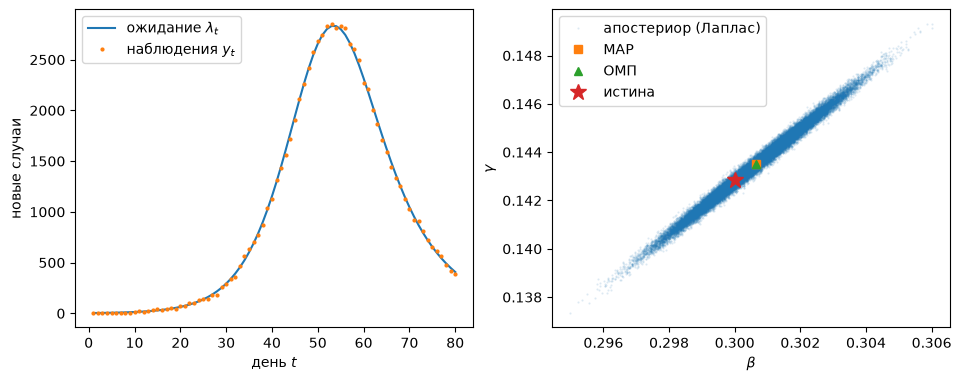

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.7), layout="constrained")
axes[0].plot(np.arange(1, T_DAYS + 1), lam_true, label="ожидание $\\lambda_t$")
axes[0].plot(np.arange(1, T_DAYS + 1), y_obs, ".", ms=4, label="наблюдения $y_t$")
axes[0].set_xlabel("день $t$")
axes[0].set_ylabel("новые случаи")
axes[0].legend()
ax = axes[1]
ax.plot(samples[:, 0], samples[:, 1], ".", ms=1, alpha=0.15, label="апостериор (Лаплас)")
ax.plot(*map_est, "s", label="MAP")
ax.plot(*mle_est, "^", label="ОМП")
ax.plot(TRUE_BETA, TRUE_GAMMA, "*", ms=12, label="истина")
ax.set_xlabel("$\\beta$")
ax.set_ylabel("$\\gamma$")
ax.legend()
fig.savefig(f"{FIGDIR}/fig-01.pdf", **SAVE_KW)

## Пример 2. Нормальное среднее: постоянный риск против сжатия

**Вопрос (theory.md: примеры «Нормальная модель с нормальным априорным
распределением» и «Нормальное среднее», задача «Минимаксная оценка среднего
нормального закона»):** риск $\overline X_N$ постоянен и равен $\sigma^2/N$,
сжатая байесовская оценка выигрывает вблизи априорного центра, но её
супремальный риск не ограничен; минимаксность $\overline X_N$ даёт
последовательность априорных $\mathcal N(0, \tau_k^2)$.

**Предсказание (до прогона).** При $N = 25$, $\sigma^2 = 1$, $\tau^2 = 1$:
риск $\overline X_N$ равен $0{,}04$ всюду; риск сжатой оценки
$c\overline X_N$, $c = 25/26$, в нуле равен $c^2/25 \approx 0{,}037$ — меньше,
а при $|\theta| \to \infty$ неограничен; байесовский риск сжатой оценки равен
$1/26 \approx 0{,}0385$; минимаксный риск $R^* = 1/25 = 0{,}04$ подтвердится
последовательностью $\tau_k^2 = k$ через формулу $\tau^2/(25\tau^2 + 1)$.

In [5]:
N = 25
SIG2 = 1.0
TAU2 = 1.0
c = N * TAU2 / (SIG2 + N * TAU2)


def risk_xbar(theta):
    return SIG2 / N + 0.0 * theta


def risk_shrunk(theta):
    return c**2 * SIG2 / N + (1 - c) ** 2 * theta**2


def bayes_risk_shrunk(tau2):
    return SIG2 * tau2 / (SIG2 + N * tau2)


theta_grid = np.linspace(-4, 4, 400)
print(f"c = N*tau^2/(sigma^2 + N*tau^2) = {c:.8f}")
print(f"R(xbar, 0)      = {risk_xbar(0):.8f}  (= sigma^2/N = {SIG2/N:.8f})")
print(f"R(shrunk, 0)    = {risk_shrunk(0):.8f}  (предсказание: c^2/25 = {c**2 / N:.8f})")
print(f"r(N(0,tau^2), shrunk) = {bayes_risk_shrunk(TAU2):.8f}  (= 1/26 = {1 / 26:.8f})")

# MC check of the risk curves at four points (seeded); the estimates are kept
# and plotted below so that the dots on the figure are the printed numbers
mc_rng = np.random.default_rng([SEED, 3])
MC = 60_000
mc_theta, mc_risk = [], []
for th in (0.0, 1.0, 2.0, 3.0):
    xbar = th + np.sqrt(SIG2 / N) * mc_rng.standard_normal(MC)
    r_hat = np.mean((c * xbar - th) ** 2)
    mc_theta.append(th)
    mc_risk.append(r_hat)
    print(f"MC R(shrunk, {th:.0f}) = {r_hat:.5f}  (точно {risk_shrunk(th):.5f})")

# Bayes risk of xbar under N(0, tau^2) is sigma^2/N for every tau (constant risk);
# the minimax value via the escaping prior sequence tau_k^2 = k:
check_golden("risk_xbar", risk_xbar(0))
check_golden("risk_shrunk_0", risk_shrunk(0))
check_golden("bayes_risk_shrunk_tau1", bayes_risk_shrunk(TAU2))
check_golden("bayes_risk_shrunk_tau10", bayes_risk_shrunk(10.0))
for k in (1, 10, 100, 10_000):
    print(f"r(N(0,{k:>5}), shrunk_k) = {bayes_risk_shrunk(k):.8f}")

print(f"sup R(shrunk) = inf (линейный рост ~ {(1 - c) ** 2:.5f} * theta^2)")

c = N*tau^2/(sigma^2 + N*tau^2) = 0.96153846
R(xbar, 0)      = 0.04000000  (= sigma^2/N = 0.04000000)
R(shrunk, 0)    = 0.03698225  (предсказание: c^2/25 = 0.03698225)
r(N(0,tau^2), shrunk) = 0.03846154  (= 1/26 = 0.03846154)
MC R(shrunk, 0) = 0.03655  (точно 0.03698)
MC R(shrunk, 1) = 0.03829  (точно 0.03846)
MC R(shrunk, 2) = 0.04246  (точно 0.04290)
MC R(shrunk, 3) = 0.05064  (точно 0.05030)
  пин risk_xbar: получено 0.04, ожидалось 0.04
  пин risk_shrunk_0: получено 0.0369822485207, ожидалось 0.036982248
  пин bayes_risk_shrunk_tau1: получено 0.0384615384615, ожидалось 0.038461539
  пин bayes_risk_shrunk_tau10: получено 0.0398406374502, ожидалось 0.039840637
r(N(0,    1), shrunk_k) = 0.03846154
r(N(0,   10), shrunk_k) = 0.03984064
r(N(0,  100), shrunk_k) = 0.03998401
r(N(0,10000), shrunk_k) = 0.03999984
sup R(shrunk) = inf (линейный рост ~ 0.00148 * theta^2)


**Вывод:** риск $\overline X_N$ — константа $0{,}04$, сжатая оценка выигрывает
при малых $|\theta|$ (в нуле $0{,}0370$) и проигрывает неограниченно при
больших; байесовские риски по последовательности априорных
$\tau_k^2 = k \to \infty$ приближаются к $0{,}04$ снизу, подтверждая
$R^* = \sigma^2/N$ и минимаксность $\overline X_N$ (лемма о последовательности
априорных). Кривые риска на рисунке — аналитические, точки — Монте-Карло.

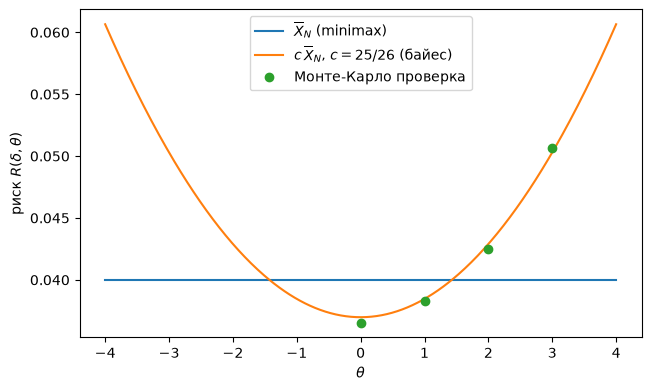

In [6]:
fig, ax = plt.subplots(figsize=(6.4, 3.8), layout="constrained")
ax.plot(theta_grid, risk_xbar(theta_grid), label="$\\overline{X}_N$ (minimax)")
ax.plot(theta_grid, risk_shrunk(theta_grid), label="$c\\,\\overline{X}_N$, $c = 25/26$ (байес)")
ax.plot(np.array(mc_theta), np.array(mc_risk), "o", ms=6, label="Монте-Карло проверка")
ax.set_xlabel("$\\theta$")
ax.set_ylabel("риск $R(\\delta, \\theta)$")
ax.legend()
fig.savefig(f"{FIGDIR}/fig-02.pdf", **SAVE_KW)

## Пример 3. Детектор на трёхточечном пространстве: седловая точка численно

**Вопрос (theory.md: теорема фон Неймана и задача «Байесовский и минимаксный
детекторы на трёхточечном пространстве»):** на конечной игре равенство
$\min_\delta \max_\theta R(\delta,\theta) = \max_\pi \min_\delta r(\pi,\delta)$
проверяется прямым счётом; минимаксный детектор рандомизирован и уравнивает
ошибки.

**Предсказание (до прогона).** Для $p = (1/2, 3/10, 1/5)$, $q = (1/5, 3/10, 1/2)$
байесовский риск как функция $\pi$ имеет максимум $7/20 = 0{,}35$ при
$\pi = 1/2$; минимаксный детектор выбирает $H_1$ на $k = 3$, $H_0$ на $k = 1$,
на $k = 2$ рандомизирует с вероятностью $1/2$, ошибки равны $0{,}35$;
наилучший детерминированный детектор даёт $1/2$, то есть рандомизация
строго улучшает минимакс.

In [7]:
from itertools import product

p = np.array([0.5, 0.3, 0.2])
q = np.array([0.2, 0.3, 0.5])
assert abs(p.sum() - 1) < 1e-12 and abs(q.sum() - 1) < 1e-12


def bayes_risk(pi):
    """Optimal 0-1 Bayes risk for prior prob pi on H1."""
    pi = np.asarray(pi, dtype=float)
    # decide H1 where pi*q_k >= (1-pi)*p_k
    pfa = np.sum(p[pi * q >= (1 - pi) * p])
    pfn = np.sum(q[pi * q < (1 - pi) * p])
    return (1 - pi) * pfa + pi * pfn


def detector_errors(t):
    """Errors of the randomized detector with P(decide H1 | X = k) = t_k."""
    t = np.asarray(t, dtype=float)
    pfa = float(t @ p)      # prob of H1 under H0
    pfn = float((1 - t) @ q)  # prob of H0 under H1
    return pfa, pfn


pi_grid = np.linspace(0, 1, 401)
br = np.array([bayes_risk(pi) for pi in pi_grid])
i_max = int(np.argmax(br))
print(f"max bayes risk = {br[i_max]:.6f} at pi = {pi_grid[i_max]:.4f}  (предсказание 0.35 при 0.5)")

# Minimax detector: H0 on k=1, H1 on k=3, coin flip on k=2
t_star = np.array([0.0, 0.5, 1.0])
pfa_star, pfn_star = detector_errors(t_star)
print(f"minimax detector: P_fa = {pfa_star:.6f}, P_fn = {pfn_star:.6f}")

# Best deterministic detector by enumeration (8 candidates)
det_best = min(max(detector_errors(np.array(t))) for t in product([0.0, 1.0], repeat=3))
print(f"best deterministic max-error = {det_best:.6f}  (предсказание 0.5)")

# LP cross-check of the minimax value:
#   min v  s.t.  t @ p <= v  (false alarm),  (1 - t) @ q <= v  (miss)
c_lp = np.array([0.0, 0.0, 0.0, 1.0])
A_ub = np.array([np.append(p, -1.0), np.append(-q, -1.0)])
res_lp = optimize.linprog(c_lp, A_ub=A_ub, b_ub=np.array([0.0, -1.0]),
                          bounds=[(0, 1)] * 3 + [(0, None)])
print(f"LP minimax value = {res_lp.fun:.6f}, t* = {np.round(res_lp.x[:3], 4)}")
check_golden("minimax_value", float(br[i_max]))
check_golden("pfa_star", pfa_star)
check_golden("det_best", det_best)

# Saddle-point identity: max_pi r*(pi) == min_delta max_j P_j(error)
print(f"равенство min max = max min: {np.isclose(br[i_max], res_lp.fun, atol=1e-9)}")

max bayes risk = 0.350000 at pi = 0.5000  (предсказание 0.35 при 0.5)
minimax detector: P_fa = 0.350000, P_fn = 0.350000
best deterministic max-error = 0.500000  (предсказание 0.5)
LP minimax value = 0.350000, t* = [0.  0.5 1. ]
  пин minimax_value: получено 0.35, ожидалось 0.35
  пин pfa_star: получено 0.35, ожидалось 0.35
  пин det_best: получено 0.5, ожидалось 0.5
равенство min max = max min: True


**Вывод:** все три числа сходятся: максимум байесовского риска по $\pi$
(кривая слева), значение ЛП по рандомизированным детекторам и ошибки
детектора с $t^* = (0, 1/2, 1)$ совпадают и равны $0{,}35$; наилучший
детерминированный детектор даёт $0{,}5$ — рандомизация улучшает минимакс
строго, как и обещала теорема фон Неймана.

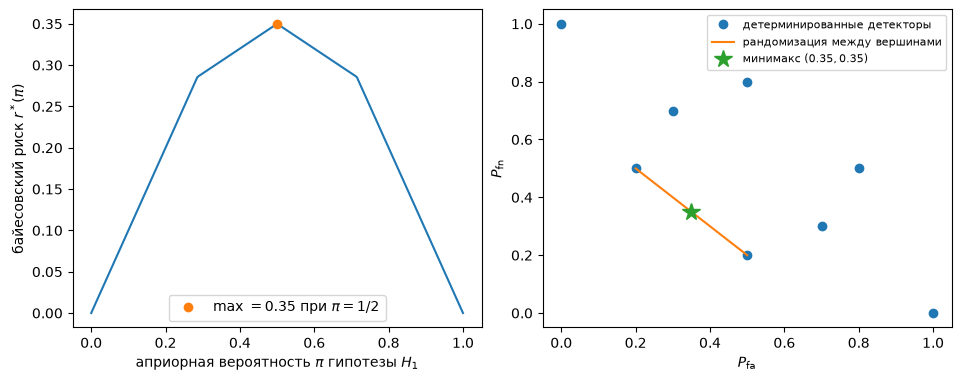

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.7), layout="constrained")
axes[0].plot(pi_grid, br)
axes[0].plot(pi_grid[i_max], br[i_max], "o", label="max $= 0.35$ при $\\pi = 1/2$")
axes[0].set_xlabel("априорная вероятность $\\pi$ гипотезы $H_1$")
axes[0].set_ylabel("байесовский риск $r^*(\\pi)$")
axes[0].legend()

# ROC of deterministic detectors and the randomization segment between the
# two LR-vertex detectors adjacent to the minimax point
pts = [detector_errors(np.array(t)) for t in product([0.0, 1.0], repeat=3)]
pts = sorted(set((round(a, 6), round(b, 6)) for a, b in pts))
xs = [a for a, _ in pts]
ys = [b for _, b in pts]
axes[1].plot(xs, ys, "o", label="детерминированные детекторы")
seg = np.linspace(0, 1, 21)
A = np.array(detector_errors(np.array([0.0, 0.0, 1.0])))
B = np.array(detector_errors(np.array([0.0, 1.0, 1.0])))
axes[1].plot((1 - seg) * A[0] + seg * B[0], (1 - seg) * A[1] + seg * B[1], "-",
             label="рандомизация между вершинами")
axes[1].plot(pfa_star, pfn_star, "*", ms=13, label="минимакс $(0.35, 0.35)$")
axes[1].set_xlabel("$P_{\\mathrm{fa}}$")
axes[1].set_ylabel("$P_{\\mathrm{fn}}$")
axes[1].legend(fontsize=8)
fig.savefig(f"{FIGDIR}/fig-03.pdf", **SAVE_KW)